📊 O que é uma Base de Dados Não Supervisionada?

A tabela que você vê é um exemplo de dados sem rótulo (sem variável target/resposta). Não temos a separação dos dados em treino e teste, isso porque nos modelos não supervisionados queremos buscar padrões/ estruturas nos dados.

🎯 Dois usos principais do Aprendizado Não Supervisionado:
1. Clustering (Agrupamento)
2. Redução de Dimensionalidade

Dados Não Supervisionados
        ↓
    [Dois Caminhos]
        ↙          ↘
   Clustering    Redução de
   (Agrupar)     Dimensionalidade
                      ↓
                 (Preparar dados)
                      ↓
            Modelo Supervisionado
            (Regressão/Classificação)

Clusterização
O agrupamento é uma técnica para dividir os dados em diferentes grupos, na qual os registros em cada grupo são semelhantes uns aos outros. Os grupos podem ser usados diretamente, analisando mais a fundo ou passados como uma característica ou resultado para um modelo de regressão ou classificação.

Grupo de Consumidores
Vamos aprender a realizar um modelo de clusterização utilizando um case de segmentação de clientes de um shopping. Como podemos criar grupos de consumidores dado algumas caracteríticas de perfis?

Sobre a base de dados:
Esse conjunto de dados ilustra alguns dados dos consumidores de um shopping. A base possui algumas features como: gênero, idade, renda anual e pontuação de gastos

In [139]:
import pandas as pd

#plot dos gráficos
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

#Algoritmos de Agrupamento 
from sklearn.cluster import KMeans, DBSCAN


#Avaliacao de desemprenho
from sklearn.metrics import adjusted_rand_score, silhouette_score
dados = pd.read_csv("mall.csv", sep=",")

In [140]:
dados.shape

(200, 5)

In [141]:
dados.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [142]:
dados.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.88,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.97,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.26,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.82,1.0,34.75,50.0,73.00,99.0


In [143]:
dados.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Text(0.5, 1.0, 'Idade de compradores')

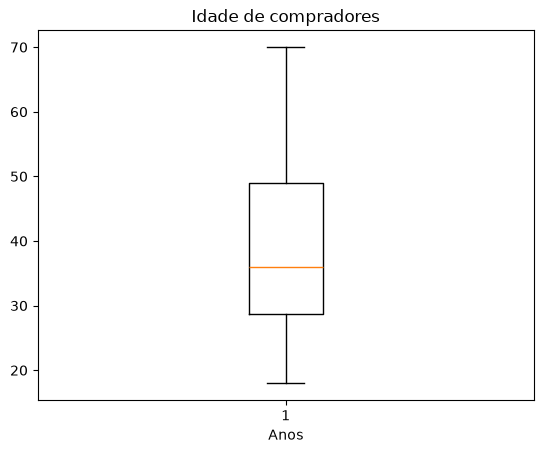

In [144]:
plt.boxplot( data = dados, x = "Age")
plt.xlabel("Anos")
plt.title("Idade de compradores")

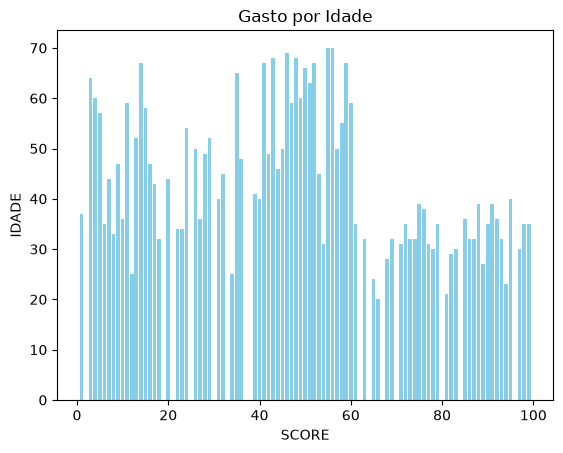

In [145]:
plt.bar( dados["Spending Score (1-100)"],dados["Age"], color ="skyblue")
plt.ylabel("IDADE")
plt.xlabel("SCORE")
plt.title("Gasto por Idade")
plt.show()

Text(0.5, 1.0, 'Score dos compradores')

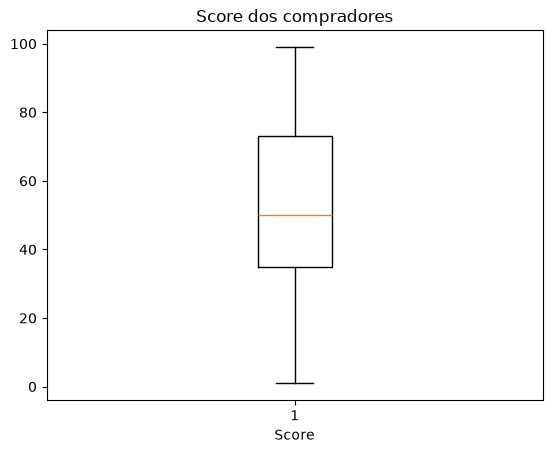

In [146]:
plt.boxplot( data = dados, x = "Spending Score (1-100)")
plt.xlabel("Score")
plt.title("Score dos compradores")

In [147]:
dados['Annual Income (k$)'].median()

np.float64(61.5)

array([[<Axes: title={'center': 'CustomerID'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Annual Income (k$)'}>,
        <Axes: title={'center': 'Spending Score (1-100)'}>]], dtype=object)

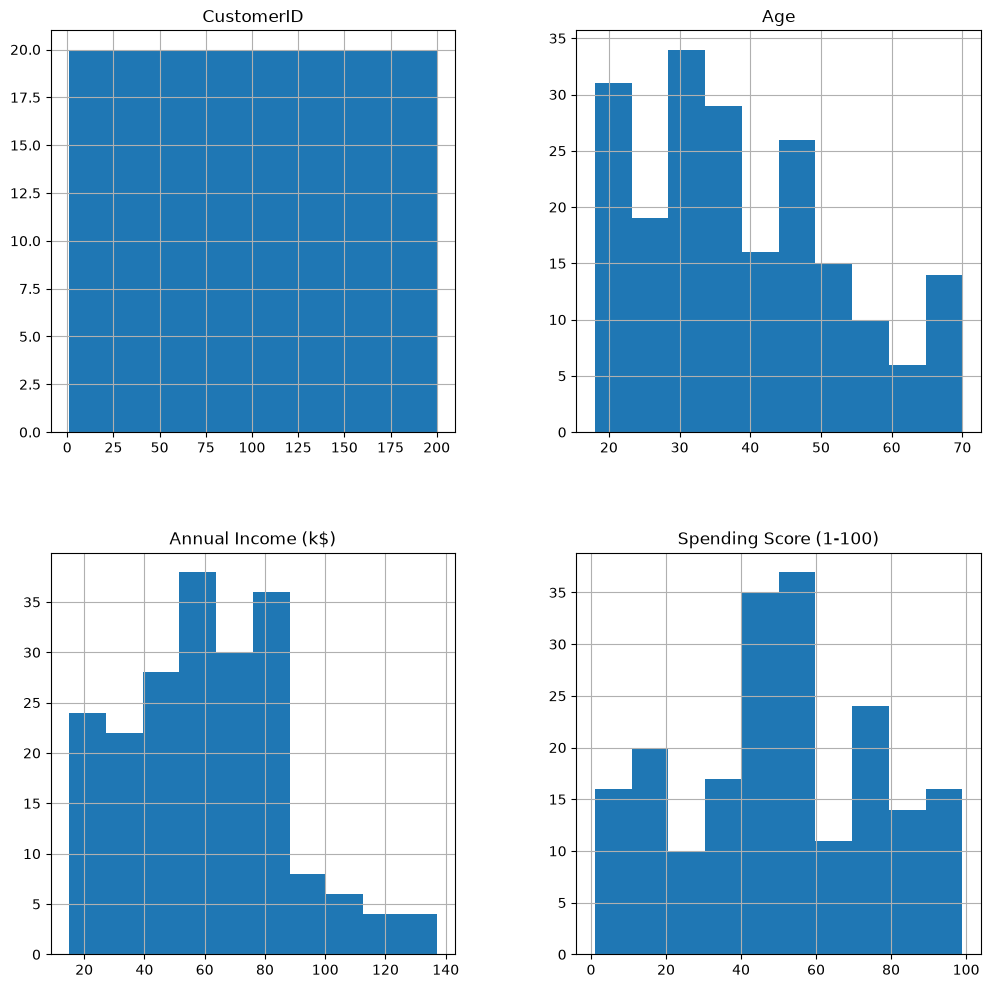

In [148]:
#Verificando todos os dados do modelo 
dados.hist(figsize=(12,12))

<Axes: >

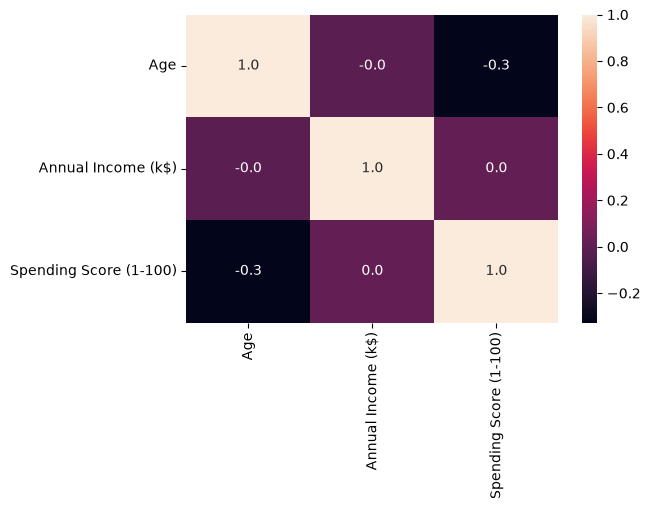

In [149]:
#Analisando correlação entre as variáveis:
plt.figure(figsize=(6,4))
sns.heatmap(dados[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr(method = 'pearson'), annot=True, fmt=".1f")

In [150]:
dados['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

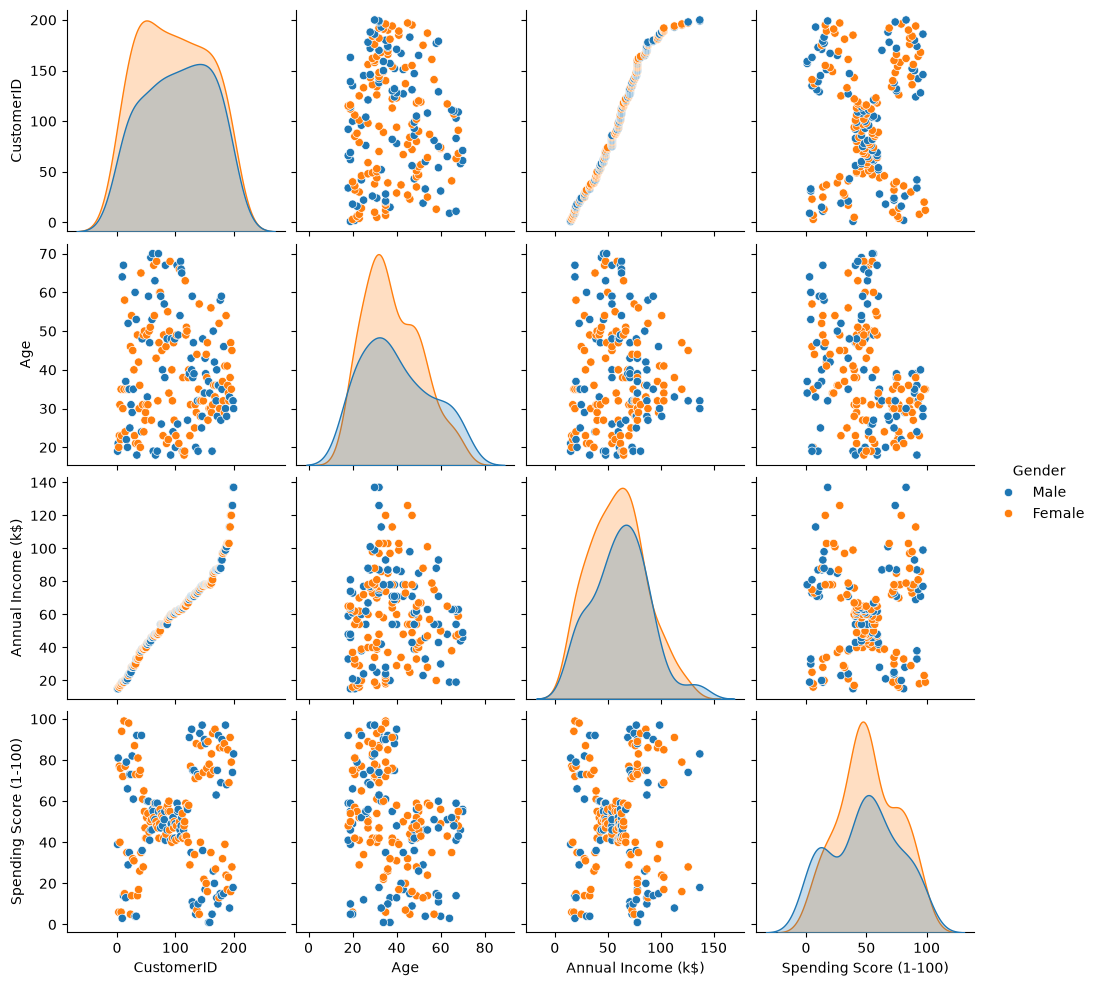

In [151]:
sns.pairplot(dados, hue="Gender")
plt.show()

************FEATURE SCALLING***********
verificando a necessidade de utilizar a padronização ou normalização dos dados ( não faz diferença na regressão linear)

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler #Feature Egineer


: 

In [153]:
scaler = StandardScaler()
#scaler = MinMaxScaler
scaler.fit(dados[['Annual Income (k$)','Spending Score (1-100)']])

StandardScaler()

In [154]:
dados_Escalonados = scaler.transform(dados[['Annual Income (k$)','Spending Score (1-100)']])

In [155]:
dados_Escalonados

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

*CRIANDO OD AGRUPAMENTOS - VAMOS CRIAR AGRUPAMENTOS COM DIFERENTES METODOLOGIAS:

1 - K-Means (saber o ponto de abastecimento de lojas)
Sobre o modelo: O K-Means parte da ideia de quebrar o espaço multidimensional de dados em partições a partir do centróide dos dados. Após inicializar os centróides de forma aleatória sobre os dados, o K-Means calcula a distância dos dados para os centros mais próximos. Esse cálculo da distância é realizado várias vezes até que os dados sejam agrupados da melhor forma possível de acordo com a distância mais próxima de um centróide (ponto centro de dado na qual será formado o grupo).

Hiperparametros: Definição do K. Para definir esse valor de K, é necessário utilizar o método Elbow para encontrar o melhor hiperparâmetros de K. O método Elbow consiste no cálculo da soma dos erros quadráticos.

Vantagens: Implementação simplificado e possui uma certa facilidade em lidar com qualquer medida de similaridade entre os dados.

Desvantagem: Difícil definir o melhor K. Sensível a outliers. Não consegue distinguir grupos em dados não-globulares.só receita, 

In [156]:
#Executando o algoritmo sem feature scaling
# Definindo o modelo de clusterizacao. K-MEANS com 6 clusters
kmeans = KMeans(n_clusters=6,random_state=0) #definindo os hiperparametros do algoritmo (definir o número de grupo = cluster)

#Implementando o K-Means nos dados:
kmeans.fit(dados[['Annual Income (k$)','Spending Score (1-100)']])

#Salvando os centroides de cada cluster
centroides = kmeans.cluster_centers_

#Salvando os labels dos clusters para cada exemplo
kmeans_labels = kmeans.predict(dados[['Annual Income (k$)','Spending Score (1-100)']])


In [157]:
# Definindo o modelo de clusterizacao. K-MEANS com 6 clusters
kmeans_escalonados = KMeans(n_clusters=6,random_state=0)

#Implementando o K-Means nos dados:
kmeans.fit(dados_Escalonados)

#Salvando os centroides de cada cluster
centroides_escalonados = kmeans.cluster_centers_

#Salvando os labels dos clusters para cada exemplo
kmeans_labels_escalonado = kmeans.predict(dados_Escalonados)

In [158]:
dados_Escalonados = pd.DataFrame(dados_Escalonados, columns = ['Annual Income (k$)','Spending Score (1-100)'])


In [159]:
dados_Escalonados.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [160]:
dados_Escalonados['Grupos'] = kmeans_labels_escalonado
dados_Escalonados.head()

,Annual Income (k$),Spending Score (1-100),Grupos
0,-1.738999,-0.434801,3
1,-1.738999,1.195704,5
2,-1.700830,-1.715913,3
3,-1.700830,1.040418,5
4,-1.662660,-0.395980,3


In [161]:
dados['Grupos'] = kmeans_labels
dados.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Grupos
0,1,Male,19,15,39,3
1,2,Male,21,15,81,5
2,3,Female,20,16,6,3
3,4,Female,23,16,77,5
4,5,Female,31,17,40,3


In [162]:
pd.Series(kmeans_labels).value_counts()

0    49
4    39
1    39
2    32
3    21
5    20
Name: count, dtype: int64

In [163]:
centroides #espaço tridimensional (salário e score de gasto)

array([[62.73469388, 46.91836735],
       [86.53846154, 82.12820513],
       [89.40625   , 15.59375   ],
       [25.14285714, 19.52380952],
       [45.51282051, 51.51282051],
       [24.95      , 81.        ]])

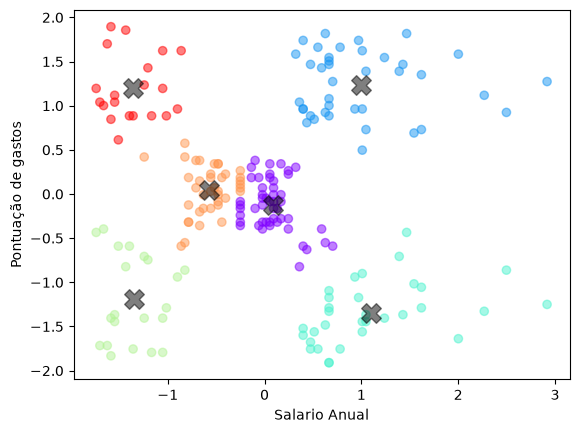

In [164]:
# plotando os dados identificando com os seus clusters
plt.scatter(dados_Escalonados[['Annual Income (k$)']],dados_Escalonados[['Spending Score (1-100)']], c=kmeans_labels_escalonado, alpha=0.5, cmap='rainbow')
plt.xlabel('Salario Anual')
plt.ylabel('Pontuação de gastos')

# plotando os centroides
plt.scatter(centroides_escalonados[:, 0], centroides_escalonados[:, 1], c='black', marker='X', s=200, alpha=0.5)
plt.rcParams['figure.figsize'] = (10, 5)
plt.show()